In [16]:
# fonction.py est resté à la racine du projet (partagé par tous les
# notebooks) : chaque notebook vivant maintenant dans son propre
# dossier, on ajoute le dossier parent au chemin d'import.
import sys, os
sys.path.append(os.path.abspath('..'))

from fonction import *

# Partie Deep Learning

Après avoir validé le modèle physique par Volumes Finis, on passe à
l'approche par apprentissage automatique:
un réseau de neurones classique (MLP) sera d'abord entraîné à reproduire
la solution analytique, avant d'introduire un PINN qui intègre directement
l'EDP dans sa fonction de coût.

##  Génération du jeu de données

Le MLP est entraîné en mode supervisé classique : on génère des couples
(x, t) → u(x, t) à partir de la solution analytique. Un sur-échantillonnage
est appliqué près du choc initial (x proche de x0, t proche de 0), car c'est
la zone où u varie le plus brutalement et où le réseau doit être le plus précis.

In [17]:
# Génération d'un jeu de données avec sur-échantillonnage renforcé
# autour du choc initial (t proche de 0, x proche de x0)

np.random.seed(0) # reproductibilité

N_total = 7000
N_focus = int(0.3 * N_total)      # 30% des points concentrés près du choc initial
N_uniform = N_total - N_focus

# Partie 1 : échantillonnage uniforme sur tout le domaine (x, t)(identique à avant)
t_unif = np.random.uniform(0, T, N_uniform)
x_unif = np.random.uniform(-L, L, N_uniform)

# Partie 2 : échantillonnage concentré près de (x0, t=0), là où u varie vite
# (loi exponentielle en t pour privilégier les temps courts, loi normale en x
#  centrée sur x0 avec l'écart-type du choc initial sigma)
t_focus = np.clip(np.random.exponential(scale=0.3, size=N_focus), 0, T)
x_focus = np.clip(np.random.normal(loc=x0, scale=sigma, size=N_focus), -L, L)

t_data2 = np.concatenate([t_unif, t_focus])
x_data2 = np.concatenate([x_unif, x_focus])
u_data2 = u_analytique(x_data2, t_data2, A, x0, sigma, D, alpha)

df = pd.DataFrame({'t': t_data2, 'x': x_data2, 'u_exacte': u_data2})
df.to_csv('dataset_diffusion.csv', index=False)

print(f"Total points : {len(df)}  (dont {N_focus} concentrés près du choc initial)")

Total points : 7000  (dont 2100 concentrés près du choc initial)


In [18]:
# --- Aperçu rapide du jeu de données ---------------------------------------

print("les lignes du DataFrame :")
print(df.head())
print("Résumé statistique du DataFrame :")
df.describe()

les lignes du DataFrame :
          t         x  u_exacte
0  2.744068  5.179377  0.004676
1  3.575947  6.348490  0.002568
2  3.013817 -4.355971  0.009573
3  2.724416 -4.896879  0.005884
4  2.118274 -1.172848  0.045470
Résumé statistique du DataFrame :


,t,x,u_exacte
count,7000.000000,7000.000000,7.000000e+03
mean,1.830358,-0.076787,3.919684e-02
std,1.580687,4.878460,4.925343e-02
min,0.000062,-9.996992,6.031054e-41
25%,0.332043,-2.815086,6.930451e-04
50%,1.448988,-0.044515,1.719647e-02
75%,3.180146,2.732844,6.385298e-02
max,4.999820,9.999559,1.978473e-01


### Visualisation des données

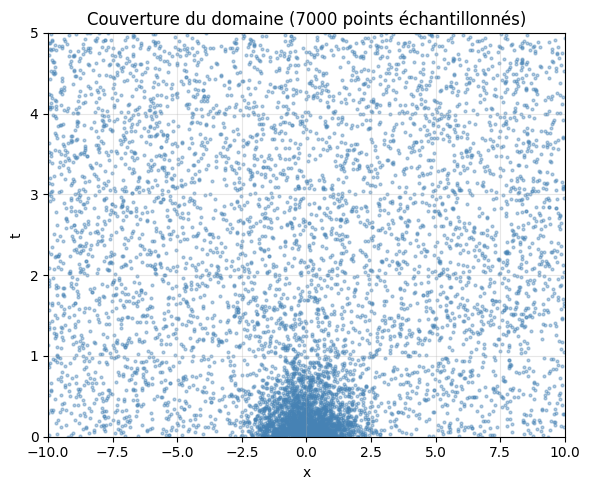

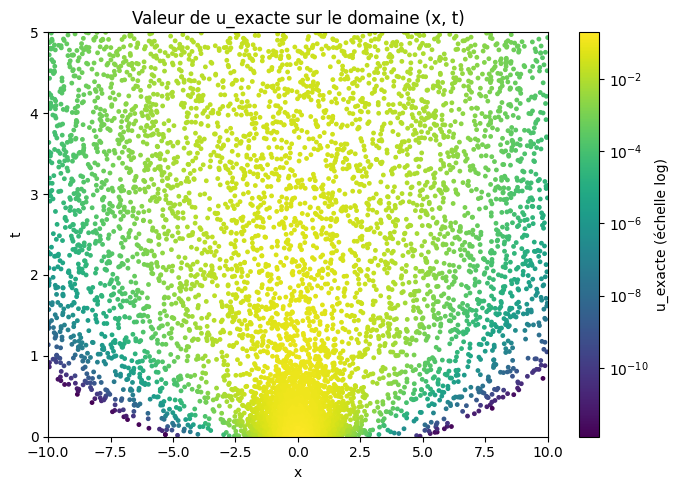

In [19]:
# ---------------------------------------------------------------------
# Graphe 1 : couverture du domaine (x, t)
# On vérifie visuellement que le sur-échantillonnage près de (x0, t=0)
# est bien visible (points plus denses dans cette zone).
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['x'], df['t'], s=4, alpha=0.4, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(f"Couverture du domaine ({len(df)} points échantillonnés)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('couverture_domaine.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------
# Graphe 2 : valeur de u_exacte sur le domaine (échelle log)
# u varie sur plusieurs ordres de grandeur entre le centre du choc et
# les zones lointaines/tardives, d'où l'usage d'une échelle logarithmique.
# ---------------------------------------------------------------------
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(7, 5))

# LogNorm exige des valeurs strictement positives : on écarte les valeurs
# numériquement nulles (en dessous d'un seuil) qui feraient planter LogNorm
mask = df['u_exacte'] > 1e-12

sc = ax.scatter(df['x'][mask], df['t'][mask], c=df['u_exacte'][mask], s=6,
                 cmap='viridis',
                 norm=LogNorm(vmin=df['u_exacte'][mask].min(),
                               vmax=df['u_exacte'][mask].max()))
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('u_exacte (échelle log)')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title("Valeur de u_exacte sur le domaine (x, t)")
ax.set_xlim(-L, L)
ax.set_ylim(0, T)
plt.tight_layout()
plt.savefig('valeur_u_exacte.png', dpi=300, bbox_inches='tight')
plt.show()

### Répartition des données

In [20]:

df = pd.read_csv('dataset_diffusion.csv')
# Étape 1 : séparer train (70%) et "temp" (30%)
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42)

# Étape 2 : séparer temp en validation (15%) et test (15%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Train : {len(df_train)} points")
print(f"Val   : {len(df_val)} points")
print(f"Test  : {len(df_test)} points")

Train : 4900 points
Val   : 1050 points
Test  : 1050 points


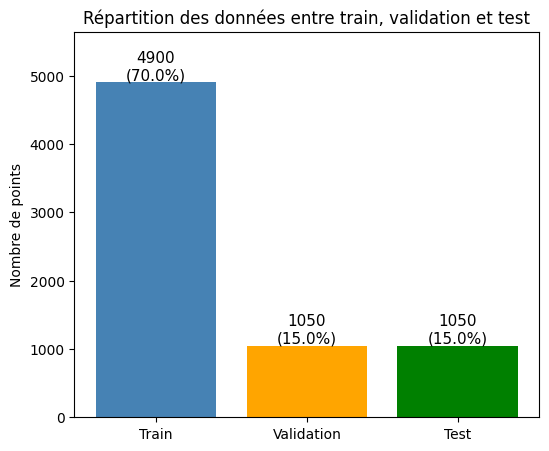

In [21]:
# --- Visualisation de la répartition des données ---------------------------
labels = ['Train', 'Validation', 'Test']
counts = [len(df_train), len(df_val), len(df_test)]
total = sum(counts)

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts, color=['steelblue', 'orange', 'green'])

for bar, count in zip(bars, counts):
    pourcentage = 100 * count / total
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{count}\n({pourcentage:.1f}%)",
              ha='center', va='bottom', fontsize=11)

plt.ylabel('Nombre de points')
plt.title("Répartition des données entre train, validation et test")
plt.ylim(0, max(counts) * 1.15)  # un peu de marge en haut pour le texte
plt.savefig('repartition_donnees.png', dpi=300, bbox_inches='tight')
plt.show()

### Normalisation des données

Le réseau de neurones s'entraîne mieux quand ses entrées et sorties sont
d'ordre de grandeur comparable. On applique donc :
- une **normalisation standard** (centrer-réduire) sur x et t ;
- un **passage au log** sur u avant normalisation, car u varie sur plusieurs
  ordres de grandeur entre le centre du choc et les zones lointaines/tardives
  (cf. visualisation en échelle log de la section précédente).

Les moyennes/écarts-types sont calculés **uniquement sur le train**, puis
réutilisés tels quels pour val et test, afin d'éviter toute fuite d'information.

In [22]:
eps = 1e-12  # évite log(0) pour les valeurs de u numériquement nulles

# --- Passage au log de u avant normalisation --------------------------------

u_log_train = np.log(df_train['u_exacte'].values + eps)
u_log_val   = np.log(df_val['u_exacte'].values + eps)
u_log_test  = np.log(df_test['u_exacte'].values + eps)

# --- Statistiques de normalisation calculées UNIQUEMENT sur le train --------
x_mean, x_std = df_train['x'].mean(), df_train['x'].std()
t_mean, t_std = df_train['t'].mean(), df_train['t'].std()
u_mean, u_std = u_log_train.mean(), u_log_train.std()

def normalize(df_subset, u_log):
    """
    Centre-réduit x et t, et centre-réduit log(u), en utilisant toujours
    les statistiques (mean, std) calculées sur le train.
    """
    x_norm = (df_subset['x'].values - x_mean) / x_std
    t_norm = (df_subset['t'].values - t_mean) / t_std
    u_norm = (u_log - u_mean) / u_std
    X = torch.tensor(np.column_stack([x_norm, t_norm]), dtype=torch.float32)
    y = torch.tensor(u_norm, dtype=torch.float32).view(-1, 1)
    return X, y

X_train, y_train = normalize(df_train, u_log_train)
X_val,   y_val   = normalize(df_val,   u_log_val)
X_test,  y_test  = normalize(df_test,  u_log_test)


In [23]:
# --- Vérification : après normalisation, X_train doit être ~ N(0, 1) -------
print(X_train.shape, y_train.shape)
print(X_train.mean(dim=0), X_train.std(dim=0))

torch.Size([4900, 2]) torch.Size([4900, 1])
tensor([ 3.8925e-10, -5.8388e-10]) tensor([1., 1.])


### Comparaison rapide d'architectures

Avant de choisir l'architecture définitive du MLP, on compare rapidement
plusieurs configurations (profondeur, largeur, fonction d'activation) sur
un entraînement court (400 époques), afin d'identifier un bon compromis
entre capacité du modèle et erreur de validation.

In [24]:
def make_mlp(n_layers, hidden, act_fn):
    """Construit un MLP simple : n_layers couches cachées de taille `hidden`,
    suivies d'une couche de sortie linéaire (1 neurone, pas d'activation)."""
    layers = [nn.Linear(2, hidden), act_fn()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden, hidden), act_fn()]
    layers += [nn.Linear(hidden, 1)]
    return nn.Sequential(*layers)

def count_params(m):
    """Nombre total de paramètres entraînables du modèle."""
    return sum(p.numel() for p in m.parameters())

def train_quick(model, epochs=400, lr=1e-3):
    """
    Entraînement court (pas de mini-batchs : tout le train à chaque époque)
    utilisé uniquement pour comparer rapidement des architectures entre elles,
    pas pour l'entraînement final.
    """

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    best_val = float('inf')
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = crit(model(X_train), y_train)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_val), y_val).item()
        if vl < best_val:
            best_val = vl
    return best_val, loss.item()

# --- Grille de configurations à comparer -----------------------------------
configs = [
    ("1x16, tanh", 1, 16, nn.Tanh),
    ("1x32, tanh", 1, 32, nn.Tanh),
    ("2x32, tanh", 2, 32, nn.Tanh),
    ("3x32, tanh", 3, 32, nn.Tanh),
    ("4x32, tanh", 4, 32, nn.Tanh),
    ("3x64, tanh", 3, 64, nn.Tanh),
    ("3x32, relu", 3, 32, nn.ReLU),
]

resultats_archi = []
print(f"{'config':15s} {'#params':>8s} {'train_mse':>12s} {'val_mse':>12s}")
for name, nl, h, act in configs:
    torch.manual_seed(0)
    m = make_mlp(nl, h, act)
    n_params = count_params(m)
    val_mse, train_mse = train_quick(m, epochs=400)
    resultats_archi.append((name, n_params, train_mse, val_mse))
    print(f"{name:15s} {n_params:8d} {train_mse:12.6f} {val_mse:12.6f}")

df_archi = pd.DataFrame(resultats_archi, columns=['config', 'n_params', 'train_mse', 'val_mse'])
df_archi.to_csv('comparaison_architectures.csv', index=False)

config           #params    train_mse      val_mse
1x16, tanh            65     0.246751     0.201504
1x32, tanh           129     0.173149     0.139552
2x32, tanh          1185     0.023519     0.016696
3x32, tanh          2241     0.012766     0.008346
4x32, tanh          3297     0.009524     0.006089
3x64, tanh          8577     0.009715     0.006422
3x32, relu          2241     0.007565     0.005171


### Architecture retenue pour le MLP

Suite à la comparaison précédente, on retient une architecture à 3 couches
cachées de 32 neurones avec activation `tanh` : un bon compromis entre
capacité de représentation et risque de sur-apprentissage sur ce problème.

In [25]:


# --- Modèle ET optimiseur créés ensemble, dans la même cellule -------------
# (évite un bug classique : optimiseur pointant vers un ancien modèle)
torch.manual_seed(0) 
model = MLP(hidden_dim=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- Vérification de synchronisation modèle / optimiseur -------------------
model_param_ids = set(id(p) for p in model.parameters())
optim_param_ids = set(id(p) for group in optimizer.param_groups for p in group['params'])
print("Modèle et optimiseur synchronisés :", model_param_ids == optim_param_ids)

Modèle et optimiseur synchronisés : True


### Entrainement de modèle

In [26]:
n_epochs = 1790
train_losses, val_losses = [], []
best_val_loss = float('inf') # on garde les poids du meilleur modèle (early-stopping "manuel")
best_model_state = None

t0 = time.perf_counter()

for epoch in range(n_epochs):
    # --- Phase d'entraînement ------------------------------------------
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    # --- Phase de validation ---------------------------------------------
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # On sauvegarde les poids si la loss de validation s'améliore
    # (protège contre le sur-apprentissage sur les dernières époques)
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_epoch = epoch
        best_model_state = snapshot_state_dict(model)  # copie réelle et indépendante

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Train loss: {loss.item():.6f} | Val loss: {val_loss.item():.6f}")
        
t_train_mlp = time.perf_counter() - t0

# --- Sécurité : best_model_state doit être une copie INDÉPENDANTE ----------
assert best_model_state is not None, (
    "Aucun meilleur modèle mémorisé : vérifier la boucle de validation.")
_w_best = next(iter(best_model_state.values()))
_w_live = next(iter(model.state_dict().values()))
assert _w_best.data_ptr() != _w_live.data_ptr(), (
    "best_model_state partage la mémoire du modèle courant : ce n'est pas "
    "une copie indépendante, la sauvegarde ne serait pas sécurisée !")

# --- On restaure les poids du meilleur modèle rencontré ---------------------
model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    check = criterion(model(X_val), y_val).item()
print(best_epoch, best_val_loss, check)


Epoch    0 | Train loss: 1.025500 | Val loss: 0.912405
Epoch  200 | Train loss: 0.044934 | Val loss: 0.034432
Epoch  400 | Train loss: 0.012739 | Val loss: 0.008332
Epoch  600 | Train loss: 0.009500 | Val loss: 0.006380
Epoch  800 | Train loss: 0.007350 | Val loss: 0.004977
Epoch 1000 | Train loss: 0.005530 | Val loss: 0.003806
Epoch 1200 | Train loss: 0.003915 | Val loss: 0.002777
Epoch 1400 | Train loss: 0.002801 | Val loss: 0.002143
Epoch 1600 | Train loss: 0.001675 | Val loss: 0.001298
1789 0.0008645137422718108 0.0008645137422718108


### Courbe d'apprentissage

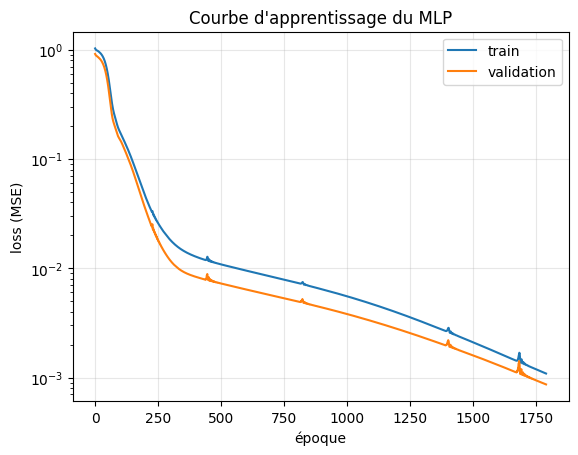

In [27]:
# --- Courbe d'apprentissage : suivi du sur/sous-apprentissage --------------
# Échelle log car la loss décroît sur plusieurs ordres de grandeur.
# Si val_losses remonte alors que train_losses continue de baisser,
# c'est un signe de sur-apprentissage.
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.yscale('log')
plt.xlabel('époque')
plt.ylabel('loss (MSE)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.title("Courbe d'apprentissage du MLP")
plt.savefig('courbe_apprentissage_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

### Évaluation du MLP sur le jeu de test

On évalue le MLP sur les données de test (jamais vues pendant
l'entraînement), après avoir inversé la transformation log + normalisation
appliquée en amont, pour comparer u_prédit et u_exact dans l'échelle physique
d'origine (et non dans l'espace normalisé/log utilisé pour l'entraînement).


In [28]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy().flatten()

# --- Dénormalisation : inverse exact de la transformation d'entraînement ---
# (norm -> log -> échelle physique)
u_log_pred = y_pred_norm * u_std + u_mean
u_pred = np.exp(u_log_pred) - eps
u_exacte_test = np.exp(u_log_test) - eps

diff = u_pred - u_exacte_test
MSE_mlp  = np.mean(diff**2)
L2_mlp   = np.sqrt(MSE_mlp)          # RMSE
MAE_mlp  = np.mean(np.abs(diff))
Linf_mlp = np.max(np.abs(diff))

print(f"Erreur MLP (test) | MSE={MSE_mlp:.3e} | L2(RMSE)={L2_mlp:.3e} | MAE={MAE_mlp:.3e} | L∞={Linf_mlp:.3e}")

Erreur MLP (test) | MSE=7.049e-06 | L2(RMSE)=2.655e-03 | MAE=1.240e-03 | L∞=2.219e-02


### Sauvegarde du modèle entraîné

On sauvegarde à la fois les poids du MLP et les paramètres de normalisation
(x_mean, x_std, t_mean, t_std, u_mean, u_std), indispensables pour réutiliser
le modèle plus tard sans avoir à ré-entraîner ou à recalculer ces statistiques.

In [29]:
# --- Sauvegarde du MLP entraîné + paramètres de normalisation ---
# (best_model_state est la copie indépendante sécurisée à la cellule
#  précédente : on ne sauvegarde jamais l'état courant de `model`.)
assert best_model_state is not None, (
    "best_model_state est vide : ré-exécuter la cellule d'entraînement "
    "du MLP avant de sauvegarder.")
torch.save({
    'model_state_dict': best_model_state,      # copie du MEILLEUR état, pas l'état courant
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'hidden_dim': 32,
    'x_mean': float(x_mean), 'x_std': float(x_std),
    't_mean': float(t_mean), 't_std': float(t_std),
    'u_mean': float(u_mean), 'u_std': float(u_std),
    'eps': float(eps),
    't_train_mlp': float(t_train_mlp),   # <-- ajouté : temps d'entraînement mesuré cellule précédente
}, '../mlp_reference.pth')

print(f"MLP sauvegardé (meilleure epoch : {best_epoch}, val = {best_val_loss:.3e})")

MLP sauvegardé (meilleure epoch : 1789, val = 8.645e-04)


### Comparaison finale : Analytique vs Volumes Finis vs MLP

On évalue maintenant le MLP entraîné sur une grille régulière (x, t) qui
couvre tout le domaine de simulation, et on superpose les trois solutions :
- la solution **analytique** (référence exacte) ;
- la solution **Volumes Finis** (référence numérique validée en partie 1) ;
- la solution **MLP** (le réseau entraîné en supervisé).

On calcule ensuite l'erreur L2 de chaque méthode numérique par rapport à
l'analytique, à chaque instant t, pour voir si l'erreur du MLP reste
comparable à celle des Volumes Finis ou si elle se dégrade (notamment loin
des zones sur-échantillonnées lors de la génération du jeu de données).

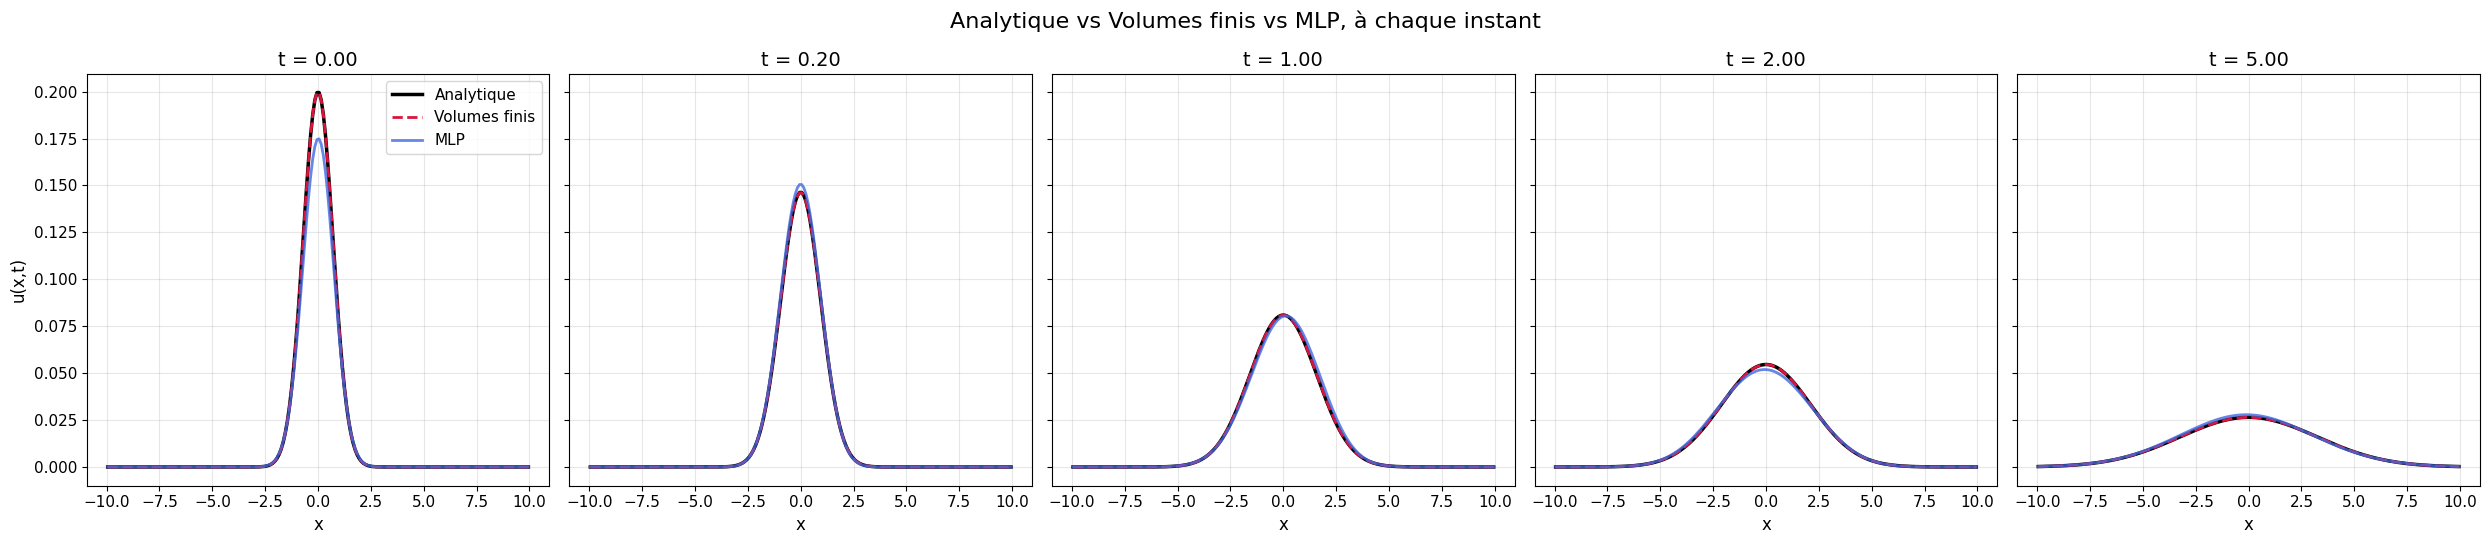

Erreur L2 max — Volumes finis : 0.000182
Erreur L2 max — MLP           : 0.025164


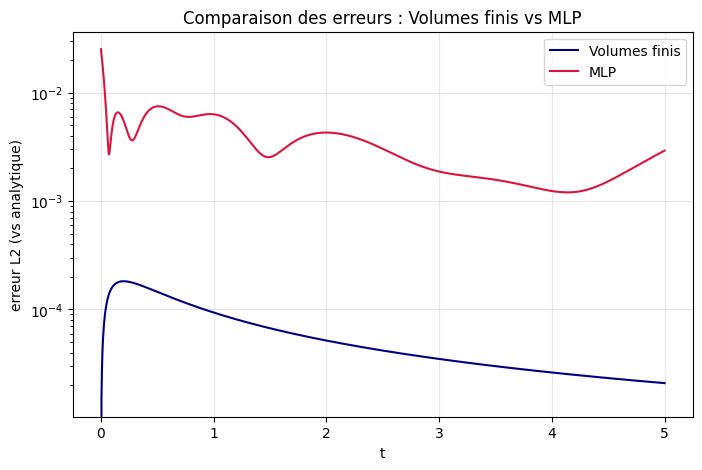

In [30]:
# --- 1) Grille de référence : on ressimule les Volumes Finis avec les paramètres de base (A, x0, sigma, D, alpha) pour avoir une solution
#     numérique fiable à comparer sur toute la grille (x, t).
t0 = time.perf_counter()
x_grille, t_grille, U_vf_grille = u_volume_finie(A=A, x0=x0, sigma=sigma, D=D, alpha=alpha, L=L, T=T, Nx=Nx)
t_vf = time.perf_counter() - t0

# --- 2) On construit le produit cartésien (x, t) de toute la grille ---
#     meshgrid donne deux tableaux 2D de forme (len(t_grille), len(x_grille)) :
#     X_mesh[i,j] = x_grille[j], T_mesh[i,j] = t_grille[i]
X_mesh, T_mesh = np.meshgrid(x_grille, t_grille)
x_flat = X_mesh.ravel()
t_flat = T_mesh.ravel()

# --- 3) IMPORTANT : on normalise (x, t) avec les MÊMES x_mean/x_std, ---
#     t_mean/t_std que ceux utilisés à l'entraînement. Le modèle n'a
#     appris qu'à interpréter des entrées normalisées, pas des (x, t) bruts.

x_flat_norm = (x_flat - x_mean) / x_std
t_flat_norm = (t_flat - t_mean) / t_std
entre_grille = torch.tensor(np.column_stack([x_flat_norm, t_flat_norm]), dtype=torch.float32)

model.eval()
with torch.no_grad():
    sortie_norm = model(entre_grille)

# --- 4) Dénormalisation : on inverse EXACTEMENT la transformation faite ---
#     avant l'entraînement (normalisation -> log). Le modèle prédit u en
#     "log normalisé", donc : dénormaliser -> exp -> retrancher eps.
u_log_pred = sortie_norm.numpy().flatten() * u_std + u_mean
U_mlp_grille = (np.exp(u_log_pred) - eps).reshape(X_mesh.shape)

# --- Graphe de comparaison des trois  solutions ---
temps_a_tracer = [1e-4, 0.2, 1, 2, T]

fig, axes = plt.subplots(1, len(temps_a_tracer), figsize=(5*len(temps_a_tracer), 5.5), sharey=True)

for ax, ti in zip(axes, temps_a_tracer):
    idx = np.argmin(np.abs(t_grille - ti))
    U_exacte_ti = u_analytique(x_grille, t_grille[idx], A, x0, sigma, D, alpha)

    ax.plot(x_grille, U_exacte_ti, color='black', linewidth=2.5, label="Analytique")
    ax.plot(x_grille, U_vf_grille[idx, :], color='crimson', linestyle='--', linewidth=2, label="Volumes finis")
    ax.plot(x_grille, U_mlp_grille[idx, :], color='royalblue', linewidth=2, alpha=0.8, label="MLP")

    ax.set_title(f"t = {ti:.2f}", fontsize=14)
    ax.set_xlabel('x', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('u(x,t)', fontsize=12)
axes[0].legend(fontsize=11)
plt.suptitle("Analytique vs Volumes finis vs MLP, à chaque instant", fontsize=16)
plt.tight_layout()
plt.savefig('comparaison_solutions.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Erreurs globales des deux méthodes par rapport à l'analytique, sur la grille ---
U_exacte_grille = np.array([u_analytique(x_grille, ti, A, x0, sigma, D, alpha) for ti in t_grille])
dx_grille = x_grille[1] - x_grille[0]

erreur_vf = U_vf_grille - U_exacte_grille
erreur_mlp = U_mlp_grille - U_exacte_grille

L2_vf = np.sqrt(dx_grille * np.sum(erreur_vf**2, axis=1))
L2_mlp = np.sqrt(dx_grille * np.sum(erreur_mlp**2, axis=1))

print(f"Erreur L2 max — Volumes finis : {L2_vf.max():.6f}")
print(f"Erreur L2 max — MLP           : {L2_mlp.max():.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_grille, L2_vf, label="Volumes finis", color='navy')
plt.plot(t_grille, L2_mlp, label="MLP", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur L2 (vs analytique)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Comparaison des erreurs : Volumes finis vs MLP")
plt.savefig('comparaison_erreurs_L2.png', dpi=300, bbox_inches='tight')
plt.show()